In [1]:
import pandas as pd
import numpy as np
import re
import jieba
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from snownlp import SnowNLP
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

print("所有库导入成功")

F:\Users\lenovo\anaconda\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


所有库导入成功


In [2]:
file_paths = {
    'KPOP偶像组': '1.kpop.xlsx',
    '华语歌手组': '2.HUAYU.xlsx',
    '本土养成系组': '3.SDFJ.xlsx'
}

df_list = []
for group_name, path in file_paths.items():
    try:
        df = pd.read_excel(path)
        df['组别'] = group_name
        df_list.append(df)
        print(f"加载成功: {group_name}，共 {len(df)} 条评论")
    except FileNotFoundError:
        print(f"文件未找到: {path}，请检查文件名是否一致")

df_all = pd.concat(df_list, ignore_index=True)
print(f"\n总计: {len(df_all)} 条评论")

加载成功: KPOP偶像组，共 3865 条评论
加载成功: 华语歌手组，共 3812 条评论
加载成功: 本土养成系组，共 481 条评论

总计: 8158 条评论


In [3]:
# 查看列名，确认评论内容在哪一列
print("列名:", df_all.columns.tolist())
df_all.head(3)

列名: ['评论内容', '评论时间', '评论者名称', '评论者id', '评论者主页', '评论者性别', '评论者头像', '评论者等级', '点赞数', '回复数', '视频总评论数', '视频链接', '一级评论id', '评论类型', '组别']


,评论内容,评论时间,评论者名称,评论者id,评论者主页,评论者性别,评论者头像,评论者等级,点赞数,回复数,视频总评论数,视频链接,一级评论id,评论类型,组别
0,道兼米啊，要一直唱下去哦,2023-08-19 14:33:00,没证据少引导,494222763,https://space.bilibili.com/494222763,保密,https://i0.hdslb.com/bfs/face/585005c2109999f0...,5,1971,4.0,3612,https://www.bilibili.com/video/BV11u4y1q74E/,181774432912,一级评论,KPOP偶像组
1,这张侧脸太美了呜呜呜呜,2023-10-29 21:11:00,被REO七页的樱桃,32465979,https://space.bilibili.com/32465979,女,https://i0.hdslb.com/bfs/face/4360613d4ed38fd6...,6,0,NaN,3612,https://www.bilibili.com/video/BV11u4y1q74E/,181774432912,二级评论,KPOP偶像组
2,请问可以求原图吗！,2023-11-03 00:44:00,精悍茶叶蛋,159079379,https://space.bilibili.com/159079379,保密,https://i2.hdslb.com/bfs/face/ca8e5f0a1f8e3e2e...,6,0,NaN,3612,https://www.bilibili.com/video/BV11u4y1q74E/,181774432912,二级评论,KPOP偶像组


In [4]:
text_col = '评论内容' 

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    # 保留中文、英文、数字、常用标点
    text = re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9，。！？、；：""''（）\n]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df_all['评论_清洗'] = df_all[text_col].apply(clean_text)

# 删除空评论
df_all = df_all[df_all['评论_清洗'].str.len() >= 2]

# 删除重复评论
df_all = df_all.drop_duplicates(subset=['评论_清洗'], keep='first')

print(f"清洗后剩余: {len(df_all)} 条评论")
print("\n各组成员数:")
print(df_all['组别'].value_counts())

清洗后剩余: 7783 条评论

各组成员数:
组别
KPOP偶像组    3691
华语歌手组      3623
本土养成系组      469
Name: count, dtype: int64


In [22]:
custom_words = [
    '孙燕姿', '周杰伦', '邓紫棋', 'BLACKPINK',
    '王橹杰', '穆祉丞', 'TF家族', '时代少年团',
    '爷青回', '破防', '泪目', '意难平', '磕到了',
    'AI翻唱', '音色', '还原', '模型', '训练',"打call",
]

for word in custom_words:
    jieba.add_word(word)

print("自定义词典加载完成")

自定义词典加载完成


In [25]:
stopwords = {
    '的', '了', '是', '我', '你', '他', '她', '它', '们', '这', '那',
    '就', '都', '也', '还', '在', '有', '没', '到', '说', '看', '听',
    '很', '太', '真', '好', '又', '更', '等', '人', '个', '种', '次',
    '吧', '吗', '呢', '啊', '哦', '嗯', '哈', '哎', '哟', '啦', '喔',
    '的', '了', '是', '我', '你', '他', '她', '它', '们', '这', '那',
    "的","了","是","我","你","他","她","它","我们","你们","他们",
    "这","那","这个","那个","这些","那些",
    "一个","一些","没有","不是","就是","但是","所以","因为",
    "而且","然后","如果","可能","应该","可以","还是",
    "啊","呀","呢","吗","吧","哦","哈","嘿","呃","em","emmm",
    "emmmmmm","hhh","hh","哈哈","哈哈哈","233","xswl",
    "真的","真的很","非常","特别","超级","有点","感觉","觉得",
    "就是","其实","然后","不过","但是","还有","以及","并且",
    "up","UP","up主","视频","评论","弹幕","播放","转发","点赞",
    "这个视频","这个歌","这个版本","这一版","这一首",
    "太","好","很","最","更","真的太","真的好",
    "有点太","有点点","超级超级",
    "现在","以前","当时","今天","昨天","明天","一直","一直在",
    "大家","有人","有人说","别人","有人觉得",
    "b站","B站","哔哩哔哩","视频区","评论区",
    "可以说","怎么说","说实话","讲真","真的说","回复",
    "最后","出来","保卫","萝卜","原来","doge","脱单","什么","怎么",
    "首歌","燕姿","陌生人","998",
    
    # ===== 新增 =====
    '这种', '时候', '自己', '已经', '一下', '这么', '本人',
    '老师', '星星', '投稿', '好好', '心心', '礼貌', '博文',
    '歌曲', '那个', '那些', '那样', '这些', '这样',
    '一直', '还是', '就是', '因为', '所以', '然后', '之后',
    '都', '也', '还', '更', '最', '很', '太', '挺',
    '吧', '呢', '啊', '哦', '嗯', '哈', '哎', '哟', '啦', '喔',
    '法尔',"不能","tv",
}

def cut_text(text):
    words = jieba.cut(str(text))
    return ' '.join(words)

def get_word_freq(text_series, n=30):
    all_text = ' '.join(text_series)
    words = all_text.split()
    freq = Counter(words)
    filtered = {w: c for w, c in freq.items() 
                if w not in stopwords and len(w) >= 2}
    return sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:n]

# 执行分词
df_all['评论_分词'] = df_all['评论_清洗'].apply(cut_text)
print("分词完成")

分词完成


In [26]:
groups = df_all['组别'].unique()

for group in groups:
    subset = df_all[df_all['组别'] == group]
    top_words = get_word_freq(subset['评论_分词'], n=30)
    print(f"\n【{group}】TOP 20 高频词:")
    for i, (word, freq) in enumerate(top_words[:20], 1):
        print(f"  {i}. {word}: {freq}")


【KPOP偶像组】TOP 20 高频词:
  1. 大哭: 1253
  2. 呜呜: 172
  3. 声音: 164
  4. 啊啊啊: 152
  5. 喜欢: 150
  6. ai: 135
  7. 委屈: 122
  8. 唱歌: 117
  9. 哭哭: 113
  10. 好听: 112
  11. 感动: 109
  12. 音色: 108
  13. 听懂: 104
  14. 打call: 104
  15. 中文: 96
  16. EXO: 93
  17. 宝宝: 89
  18. 伟大: 86
  19. 听到: 81
  20. 好像: 79

【华语歌手组】TOP 20 高频词:
  1. 孙燕姿: 492
  2. ai: 385
  3. AI: 341
  4. 歌手: 280
  5. 好听: 198
  6. 音色: 189
  7. 周杰伦: 135
  8. 声音: 129
  9. 翻唱: 91
  10. 喜欢: 90
  11. 大哭: 84
  12. 冷门: 64
  13. 发如雪: 64
  14. 以后: 59
  15. 感情: 58
  16. 知道: 56
  17. 不会: 55
  18. 模仿: 52
  19. 吃瓜: 49
  20. 唱歌: 48

【本土养成系组】TOP 20 高频词:
  1. 打call: 88
  2. 喜欢: 55
  3. 音色: 54
  4. 声音: 30
  5. 好听: 30
  6. 马嘉祺: 29
  7. 大哭: 28
  8. 张函瑞: 18
  9. 委屈: 15
  10. 啊啊啊: 13
  11. ai: 12
  12. 刘耀文: 12
  13. 适合: 11
  14. 一起: 11
  15. 感谢: 10
  16. 张桂源: 10
  17. 函瑞: 10
  18. 厉害: 10
  19. 谢谢: 10
  20. 合作: 10


In [16]:
def get_sentiment(text):
    try:
        return SnowNLP(text).sentiments
    except:
        return 0.5

df_all['情感得分'] = df_all['评论_清洗'].apply(get_sentiment)

df_all['情感标签'] = df_all['情感得分'].apply(
    lambda x: '正面' if x > 0.65 else ('负面' if x < 0.35 else '中性')
)

print("情感分析完成")
print("\n总体情感分布:")
print(df_all['情感标签'].value_counts())

情感分析完成

总体情感分布:
情感标签
正面    4207
中性    1919
负面    1657
Name: count, dtype: int64


In [17]:
# 各组情感分布
sentiment_dist = df_all.groupby('组别')['情感标签'].value_counts(normalize=True).unstack()
print("=== 各组情感分布 ===")
print(sentiment_dist)

# 各组平均情感得分
mean_sentiment = df_all.groupby('组别')['情感得分'].mean()
print("\n=== 各组平均情感得分 ===")
print(mean_sentiment)

=== 各组情感分布 ===
情感标签           中性        正面        负面
组别                                   
KPOP偶像组  0.247358  0.596315  0.156326
华语歌手组    0.252277  0.475297  0.272426
本土养成系组   0.196162  0.605544  0.198294

=== 各组平均情感得分 ===
组别
KPOP偶像组    0.681569
华语歌手组      0.588624
本土养成系组     0.669004
Name: 情感得分, dtype: float64


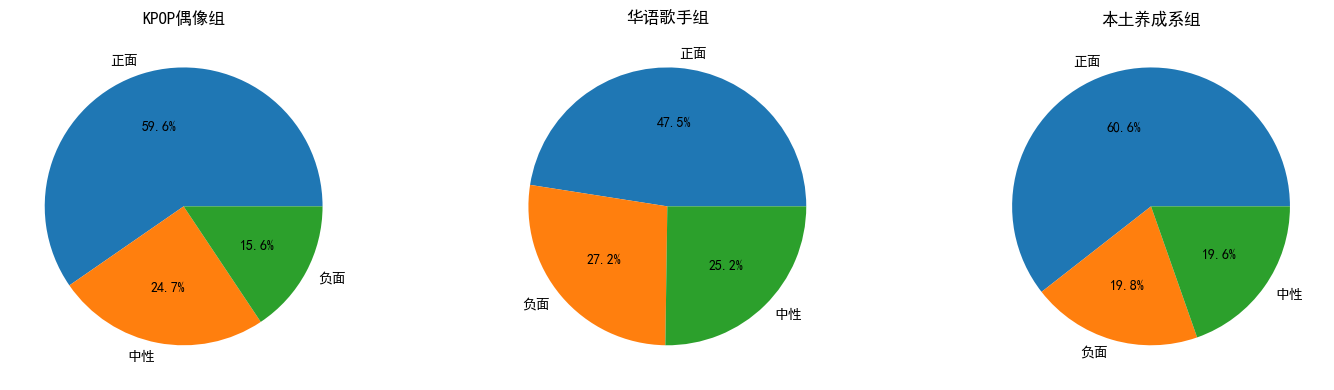

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, group in enumerate(groups):
    subset = df_all[df_all['组别'] == group]
    subset['情感标签'].value_counts().plot(
        kind='pie', autopct='%1.1f%%', ax=axes[i]
    )
    axes[i].set_title(f'{group}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig('情感分布.png', dpi=150)
plt.show()

In [27]:
compensation_keywords = {
    # ===== 愿望代偿 =====
    '愿望代偿': [
        # 直接表达愿望实现
        '终于', '总算', '可算', '圆梦', '如愿', '满足了', '实现了',
        # 表达期待/希望
        '期待', '希望', '盼望', '渴望', '想听', '好想', '多想', 
        # 想听真人唱
        '真人唱', '现场唱', '现场版', '演唱会', '出道', '投票', '出道吧',
        # 表达愿望的具体内容
        '想听', '想看你', '能不能', '可不可以', '什么时候',
        # 表达“这首歌适合XX”的愿望
        '适合', '适配', '贴', '合适', '完美', 
        # 感谢UP主实现了愿望
        '谢谢up', '感谢up',
        # 具体的愿望代偿表达
        '满足了', '知足了', '够了',
        # 中性/反向
        '不够', '还想要',
    ],
    
    # ===== 记忆代偿 =====
    '记忆代偿': [
        # 直接怀旧
        '怀念', '想念', '思念', '怀旧',
        # 时间标记
        '青春', '青春回来了', '童年', '当年', '以前', '那时候', '从前',
        # 记忆/回忆
        '回忆', '回忆杀', '记忆', '想起', '记得', '忘不了',
        # 遗憾/可惜
        '遗憾', '可惜', '惋惜', '意难平', '泪目', '哭了', '哭了',
        # 假设/如果能
        '如果', '如果还在', '要是', '假如',
        # 复活/归来
        '回来', '回来了', '归来', '回归', '复活', '重生', '复活了',
        # 感叹时间
        '时间', '时光', '岁月', '那年', '那年的', '多年',
        # 情感触动
        '破防', '绷不住了', '绷不住', '扛不住',
        # 经典/曾经
        '经典', '曾经的', '当年',
        # 情感共鸣
        '落泪',
    ],
    
    # ===== 参与式代偿 =====
    '参与式代偿': [
        # 技术/制作
        '模型', '训练', '训练模型', '调音', '调教', '调校',
        '制作', '制作的', '做了', '做的', '跑的', '跑的模型',
        # 求资源
        '求', '求完整版', '求音源', '求下载', '求资源',
        # 互动/反馈
        '投稿', '上传', '发布', '更新', '下一首', '下一期',
        # 创作者称呼
        'up主', 'UP主', 'UP', 'up', '作者', '博主', '老师', # "老师"在粉丝文化中常指代产出内容的创作者
        # 互动表达
        '催更', '蹲', '蹲一个', '期待更新',
        # 技术评价
        '厉害', '牛', '好厉害', '太强了', '神仙',
        # 声线/训练
        '声线', '声库',
    ],
    
    # ===== 社群代偿 =====
    '社群代偿': [
        # CP相关
        '磕', '磕到了', 'cp', 'CP', '好磕', '好磕的',
        # 找到同好
        '原来', '原来不只我', '原来你', '原来大家都是',
        '终于找到了', '找到同好', '找到组织',
        # 群体认同
        '同担', '家人', '来了', '集合', '报道', '报到', 
        '我来了', '我们',
        # 共同感受
        '一起', '一起哭', '一样', '大家都是', '果然',
        '我就知道', '不止我一个', '不止我',
        # 共鸣表达
        '共鸣', '同感', '深有同感', '感同身受', '我也是',
        # 群体回应
        '懂了', '明白了',
        # 社群互动
        '打call', 'call', '支持', '顶', '冲', '加油',
        '点赞', '投币',
        # 粉丝身份
        '粉', '粉丝', '团粉', '唯粉',
        # 群体情感
        '一起听',
    ],
    
    # ===== 反向表达 =====
    '反向表达': [
        # 质疑没感情
        '没感情', '没有感情', '无感情', '机械', '僵硬', 
        '冰冷', '冷冰冰', '没有灵魂', '无灵魂', '没有温度',
        # 不像/不还原
        '不像', '不太像', '根本不', '完全不像',
        '不还原', '不真实', '假', '太假', '假唱', 
        '不是本人', '不如原唱', '比不上原唱',
        # 反对/抵触
        '没必要', '有什么必要', '不理解', '无法理解',
        '侵权', '版权', '争议', '不好', '难听', 
        '禁止', '不要', '不该', '不能', '没意义',
        # 还是原唱好
        '还是原唱', '原唱更好', '原唱好听', '原唱yyds',
        # 技术批评
        '不像真人', '太机械',
        # 无感
        '无感', '没感觉',
    ],
}

In [28]:
def encode_compensation(text):
    text = str(text)
    types = []
    for type_name, keywords in compensation_keywords.items():
        if any(kw in text for kw in keywords):
            types.append(type_name)
    return types if types else ['无代偿']

df_all['代偿类型'] = df_all['评论_清洗'].apply(encode_compensation)
df_all['有代偿'] = df_all['代偿类型'].apply(lambda x: '无代偿' not in x)

print("情感代偿编码完成")

情感代偿编码完成


In [29]:
# 总体
has_comp_ratio = df_all['有代偿'].mean()
print(f"有情感代偿表达的评论占比: {has_comp_ratio:.1%}")

# 各组
print("\n=== 各组有代偿占比 ===")
print(df_all.groupby('组别')['有代偿'].mean())

# 各类代偿出现次数
all_types = [t for sublist in df_all['代偿类型'] for t in sublist if t != '无代偿']
type_counts = Counter(all_types)
print("\n=== 总体代偿类型出现次数 ===")
for t, c in type_counts.most_common():
    print(f"  {t}: {c}")

有情感代偿表达的评论占比: 33.9%

=== 各组有代偿占比 ===
组别
KPOP偶像组    0.367109
华语歌手组      0.296163
本土养成系组     0.445629
Name: 有代偿, dtype: float64

=== 总体代偿类型出现次数 ===
  社群代偿: 885
  参与式代偿: 818
  记忆代偿: 667
  愿望代偿: 587
  反向表达: 419


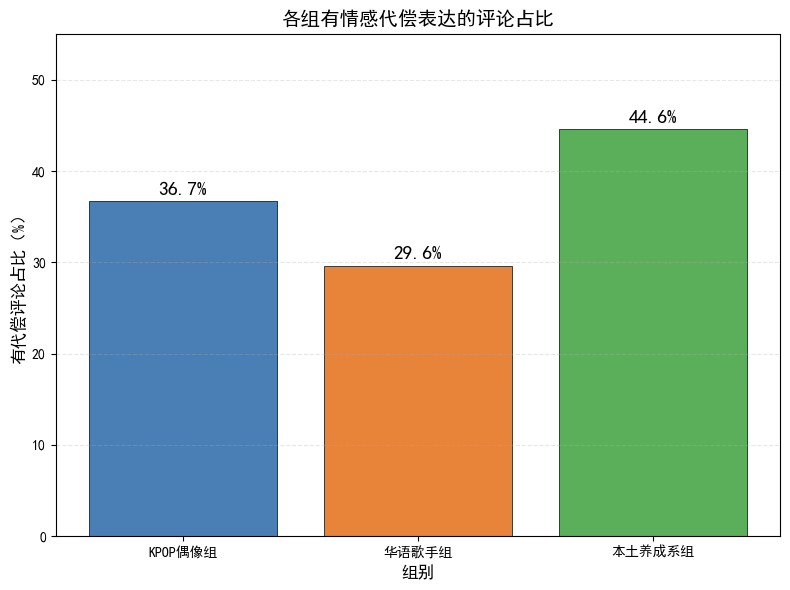

In [38]:

groups = ['KPOP偶像组', '华语歌手组', '本土养成系组']
ratios = [36.7, 29.6, 44.6]

# 颜色设置（三组固定配色：蓝/橙/绿）
colors = ['#4A7FB5', '#E8833A', '#5BAF5B']

plt.figure(figsize=(8, 6))
bars = plt.bar(groups, ratios, color=colors, edgecolor='black', linewidth=0.5)

# 在柱子上标注数值
for bar, ratio in zip(bars, ratios):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{ratio}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.xlabel('组别', fontsize=12)
plt.ylabel('有代偿评论占比（%）', fontsize=12)
plt.title('各组有情感代偿表达的评论占比', fontsize=14, fontweight='bold')
plt.ylim(0, 55)

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('有代偿占比柱状图.png', dpi=300)
plt.show()

In [36]:
# 按组计算各类代偿的百分比（占该组总评论数的比例）
for group in groups:
    subset = df_all[df_all['组别'] == group]
    total = len(subset)  # 该组总评论数
    print(f"\n=== {group} ===")
    for comp_type in ['愿望代偿', '记忆代偿', '参与式代偿', '社群代偿', '反向表达']:
        count = subset[subset['代偿类型'].apply(lambda x: comp_type in x)].shape[0]
        pct = count / total * 100
        print(f"  {comp_type}: {count}次 ({pct:.1f}%)")


=== KPOP偶像组 ===
  愿望代偿: 298次 (8.1%)
  记忆代偿: 425次 (11.5%)
  参与式代偿: 356次 (9.6%)
  社群代偿: 561次 (15.2%)
  反向表达: 108次 (2.9%)

=== 华语歌手组 ===
  愿望代偿: 238次 (6.6%)
  记忆代偿: 214次 (5.9%)
  参与式代偿: 351次 (9.7%)
  社群代偿: 234次 (6.5%)
  反向表达: 291次 (8.0%)

=== 本土养成系组 ===
  愿望代偿: 51次 (10.9%)
  记忆代偿: 28次 (6.0%)
  参与式代偿: 111次 (23.7%)
  社群代偿: 90次 (19.2%)
  反向表达: 20次 (4.3%)


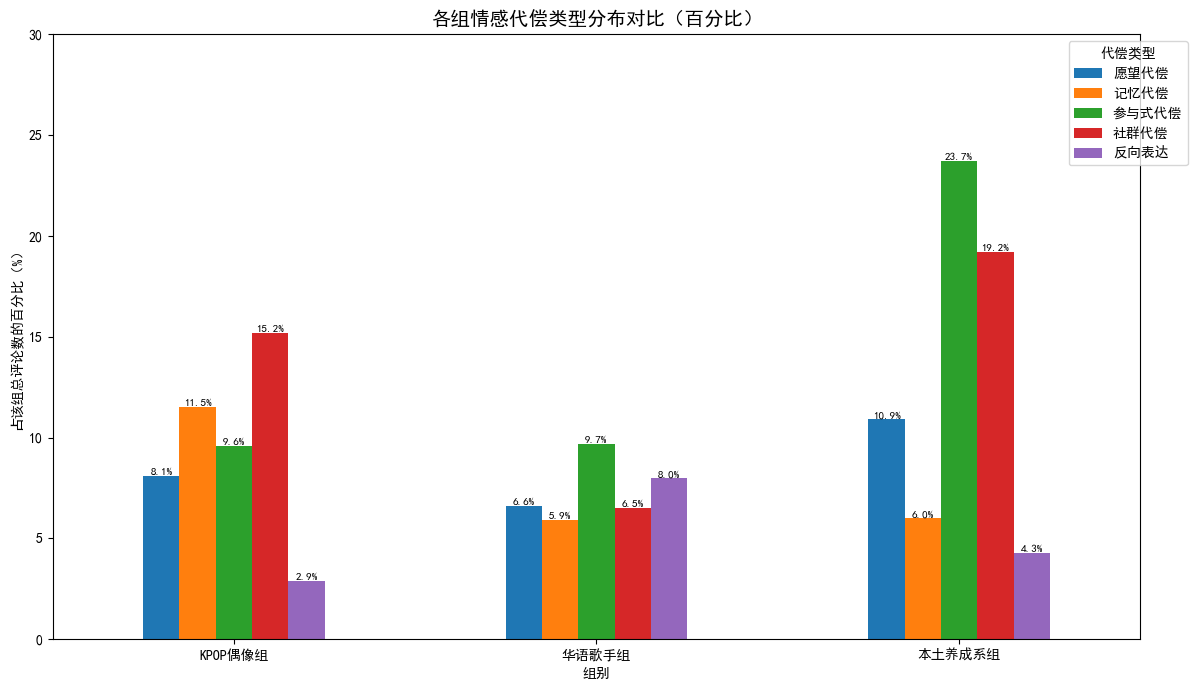

In [37]:
# ===== 各组代偿类型分布（百分比）柱状图 =====

# 构建百分比数据
comp_pct_df = pd.DataFrame({
    'KPOP偶像组': [8.1, 11.5, 9.6, 15.2, 2.9],
    '华语歌手组': [6.6, 5.9, 9.7, 6.5, 8.0],
    '本土养成系组': [10.9, 6.0, 23.7, 19.2, 4.3]
}, index=['愿望代偿', '记忆代偿', '参与式代偿', '社群代偿', '反向表达'])

# 转置，使组别为行、代偿类型为列，方便绘图
comp_pct_plot = comp_pct_df.T

# 绘图
comp_pct_plot.plot(kind='bar', figsize=(12, 7))
plt.title('各组情感代偿类型分布对比（百分比）', fontsize=14)
plt.xlabel('组别')
plt.ylabel('占该组总评论数的百分比（%）')
plt.legend(title='代偿类型', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.ylim(0, 30)  # 最高23.7%，留一点余量

# 在柱子上添加数值标签
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f%%', fontsize=8)

plt.tight_layout()
plt.savefig('代偿类型分布_百分比.png', dpi=300)
plt.show()

In [33]:
# 筛选KPOP组中“有代偿”的评论，按点赞数排序，取前10条
kpop_top = df_all[(df_all['组别']=='KPOP偶像组') & (df_all['有代偿']==True)] \
           .nlargest(10, '点赞数')[['评论_清洗', '点赞数', '代偿类型']]

kpop_top

,评论_清洗,点赞数,代偿类型
31,听了ai之后才发现原来我还是在意语言的,14141,[社群代偿]
6,ai有时确实是能弥补一些遗憾的,14002,[记忆代偿]
651,女孩纸的指路来了 aespa 宁01 40 冬02 07 Ive 张元英01 55 Red ...,5492,[社群代偿]
102,突然想到如果这首歌的副歌能够给到雪莉 具荷拉 钟铉 文彬他们会不会更泪目,5040,[记忆代偿]
95,这已经超过了一个AI作品了，更像是爱豆与粉丝的交心，有一种他们对我的回应，谢谢up主作出这么...,4743,"[愿望代偿, 参与式代偿, 社群代偿]"
261,硕米好好听，要是双主唱都在就好了,4672,[记忆代偿]
158,好震撼，这就是Kpop的力量吗，里面其实有几位我说不上喜欢的几位但是这么多人的去唱一首歌，这...,4421,[反向表达]
274,奔着田柾国点进来的，，开头完全被震惊到，于是听完了一首歌，感叹up调的真好，这是一首很有意义的ai,3933,[参与式代偿]
307,好多骂up让最后一句不应该给签的，我承认他犯了错，自从他出事之后，我真的没有再听他的歌，up...,3510,"[记忆代偿, 参与式代偿]"
194,up主你。。特别特别伟大特别特别会。。。最后的地人连唱已是绝杀，怎么想出来的，非粉都会感慨,2636,"[参与式代偿, 社群代偿]"


In [34]:
# 筛选华语组中包含“反向表达”的评论，按点赞数排序
huayu_reverse = df_all[(df_all['组别']=='华语歌手组') & 
                        (df_all['代偿类型'].apply(lambda x: '反向表达' in x))] \
                .nlargest(10, '点赞数')[['评论_清洗', '点赞数', '代偿类型']]

huayu_reverse

,评论_清洗,点赞数,代偿类型
4389,一听假，这是燕姿01年左右的音色，那时候还没有发如雪 滑稽,12537,"[记忆代偿, 反向表达]"
4973,AI孙燕姿能不能拿赛博金曲奖最佳新人,309,"[愿望代偿, 反向表达]"
4540,这样估计就不会出现只有音色像 唱法不像的情况了,80,[反向表达]
5065,音色甚至唱腔都可以模仿，但处理歌曲的方式和理解是无法被模仿的，这是最不像的部分。毕竟前者是乐...,77,"[记忆代偿, 反向表达]"
4738,妙啊 不用偷偷听啊，应该会好奇听听ai唱的像不像,58,[反向表达]
4984,都是装的，普通人也就听一响。如果孙燕姿自己账号发了这首歌还会有人说是ai唱的吗？人在面对自己...,50,"[记忆代偿, 反向表达]"
5018,我最烦所谓的全新演绎，大部分都没原唱好听，无非是粉丝滤镜罢了,47,"[社群代偿, 反向表达]"
4743,回复 餘下安生 是燕姿的私人号，不好放截图,30,[反向表达]
5100,机械永生第一阶段，音源上传 doge,30,"[参与式代偿, 反向表达]"
5113,再过几年技术成熟了，虚拟人完美取代了歌手，唱片公司是最开心的，没有签约费广告费等一堆费用，成...,25,"[愿望代偿, 反向表达]"


In [35]:
# 筛选本土组中“有代偿”的评论，按点赞数排序
local_top = df_all[(df_all['组别']=='本土养成系组') & (df_all['有代偿']==True)] \
            .nlargest(10, '点赞数')[['评论_清洗', '点赞数', '代偿类型']]

local_top

,评论_清洗,点赞数,代偿类型
7947,那一段英文念白给张函瑞太适合了 对味儿！他口语也很好 而且我总感觉有一天会从他个韩娱弟嘴里听...,412,[愿望代偿]
7759,doge 荣耀之战能不能让我看到你们合作这个，哪怕像棍铲那样背对背We don 39 t t...,403,"[愿望代偿, 反向表达]"
7766,合唱的时候我鸡皮疙瘩都起来了，无法想象如果这是真的我会是个多幸福的小女孩,183,"[记忆代偿, 社群代偿]"
7769,真的有劳斯做出来了，第一次听到这首歌就很想听他俩一起唱了 保卫萝卜 哭哭 保卫萝卜 哭哭 保...,170,"[愿望代偿, 社群代偿]"
7952,张函瑞好适合啊 星星眼,149,[愿望代偿]
7703,貌似是把发声技巧都完善后的所有人音色最适配的效果。,133,[愿望代偿]
7716,我好喜欢王橹杰的音色，太好听了，老师好厉害啊,129,[参与式代偿]
7944,没有带左航的原因是因为他的模型需要调试一下，目前没办法做他的声音,104,[参与式代偿]
7677,原来恋人不只属于正在相爱的人，也属于那些停在回忆里的脚步、解不开的鞋带、反复卡住的磁带，和心...,78,"[愿望代偿, 记忆代偿, 社群代偿]"
7771,还有首汪苏泷的 眼泪落下之前 我觉得词也特别适合他俩,72,[愿望代偿]
